# Exploratory Data Analysis and Feature Engineering

## Objective

This notebook explores the cleaned World Bank dataset and prepares the data for machine-learning modelling.

The main tasks are:

- Explore GDP growth and predictor variables.
- Create lagged GDP-growth features.
- Create the next-year GDP-growth target.
- Create GDP-per-capita economic groups.
- Define the chronological train and test periods.

Missing FDI values will be handled after the chronological split in the modelling notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

## 1. Load the cleaned dataset

In [2]:
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

clean_path = (
    project_root
    / "data"
    / "processed"
    / "clean_wdi_eu27_1995_2025.csv"
)

data = pd.read_csv(clean_path)

print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

data.head()

Rows: 837
Columns: 14


,Country Code,Country Name,Year,fdi_inflows_percent_gdp,inflation,government_consumption_percent_gdp,exports_percent_gdp,gross_fixed_capital_formation,imports_percent_gdp,gdp_growth,gdp_per_capita,unemployment,population_growth,trade_openness
0,AUT,Austria,1995,0.760156,2.243366,19.913675,33.665001,25.681435,34.860005,2.667984,33603.427826,4.345,0.153106,68.525006
1,AUT,Austria,1996,1.832365,1.860971,19.919978,34.437736,25.979239,36.031581,2.215767,34301.656215,5.282,0.135020,70.469316
2,AUT,Austria,1997,1.260587,1.305979,19.907484,37.214434,25.541074,38.030042,2.145835,34998.032117,5.150,0.113317,75.244476
3,AUT,Austria,1998,2.106185,0.922467,19.880590,38.561591,25.582850,38.787931,3.492880,36180.749057,5.483,0.109728,77.349522
4,AUT,Austria,1999,1.374399,0.568994,20.132107,39.509313,25.079147,39.053620,3.761924,37468.869887,4.699,0.194563,78.562933


## 2. Initial data checks

We check:

- Data types
- Missing values
- Country coverage
- Year coverage
- Duplicate observations

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 837 entries, 0 to 836
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Country Code                        837 non-null    str    
 1   Country Name                        837 non-null    str    
 2   Year                                837 non-null    int64  
 3   fdi_inflows_percent_gdp             823 non-null    float64
 4   inflation                           837 non-null    float64
 5   government_consumption_percent_gdp  837 non-null    float64
 6   exports_percent_gdp                 837 non-null    float64
 7   gross_fixed_capital_formation       837 non-null    float64
 8   imports_percent_gdp                 837 non-null    float64
 9   gdp_growth                          837 non-null    float64
 10  gdp_per_capita                      837 non-null    float64
 11  unemployment                        837 non-null    floa

In [4]:
print("Countries:", data["Country Code"].nunique())
print("Minimum year:", data["Year"].min())
print("Maximum year:", data["Year"].max())

print("\nDuplicate rows:", data.duplicated().sum())

print("\nMissing values:")
print(data.isna().sum().sort_values(ascending=False).to_string())

Countries: 27
Minimum year: 1995
Maximum year: 2025

Duplicate rows: 0

Missing values:
fdi_inflows_percent_gdp               14
Country Code                           0
Country Name                           0
Year                                   0
inflation                              0
government_consumption_percent_gdp     0
exports_percent_gdp                    0
gross_fixed_capital_formation          0
imports_percent_gdp                    0
gdp_growth                             0
gdp_per_capita                         0
unemployment                           0
population_growth                      0
trade_openness                         0


## 3. Explore GDP growth

GDP growth is the target variable that we will eventually predict for the following year.

In [5]:
data["gdp_growth"].describe()

count    837.000000
mean       2.637076
std        3.725256
min      -16.040020
25%        1.017796
50%        2.676346
75%        4.417253
max       24.623986
Name: gdp_growth, dtype: float64

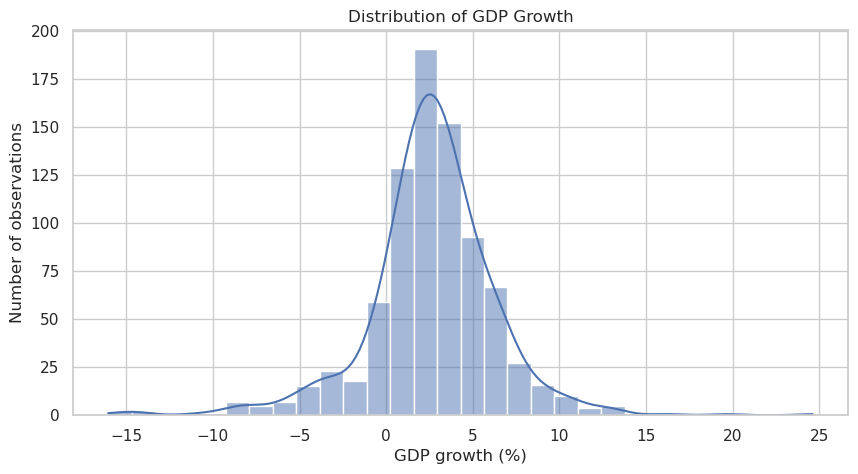

In [6]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=data,
    x="gdp_growth",
    bins=30,
    kde=True
)

plt.title("Distribution of GDP Growth")
plt.xlabel("GDP growth (%)")
plt.ylabel("Number of observations")
plt.show()

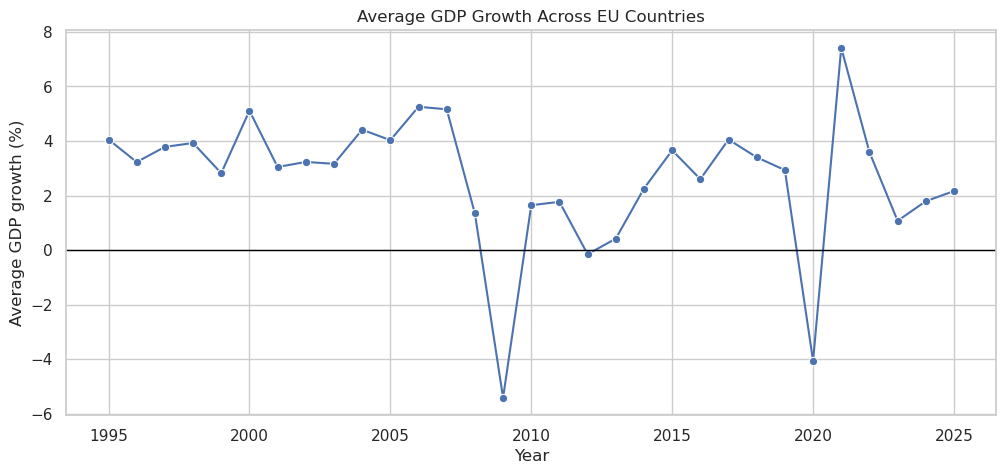

In [7]:
average_growth_by_year = (
    data
    .groupby("Year", as_index=False)["gdp_growth"]
    .mean()
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=average_growth_by_year,
    x="Year",
    y="gdp_growth",
    marker="o"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Average GDP Growth Across EU Countries")
plt.xlabel("Year")
plt.ylabel("Average GDP growth (%)")
plt.show()

## 4. Explore GDP growth by country

Different EU countries may have different growth patterns and levels of volatility.

In [8]:
country_average_growth = (
    data
    .groupby(["Country Code", "Country Name"], as_index=False)
    ["gdp_growth"]
    .mean()
    .sort_values("gdp_growth")
)

country_average_growth

,Country Code,Country Name,gdp_growth
15,ITA,Italy,0.787942
11,GRC,Greece,1.172515
5,DEU,Germany,1.184355
10,FRA,France,1.562195
0,AUT,Austria,1.616846
22,PRT,Portugal,1.621038
6,DNK,Denmark,1.743697
1,BEL,Belgium,1.798315
9,FIN,Finland,1.829808
20,NLD,Netherlands,2.017632


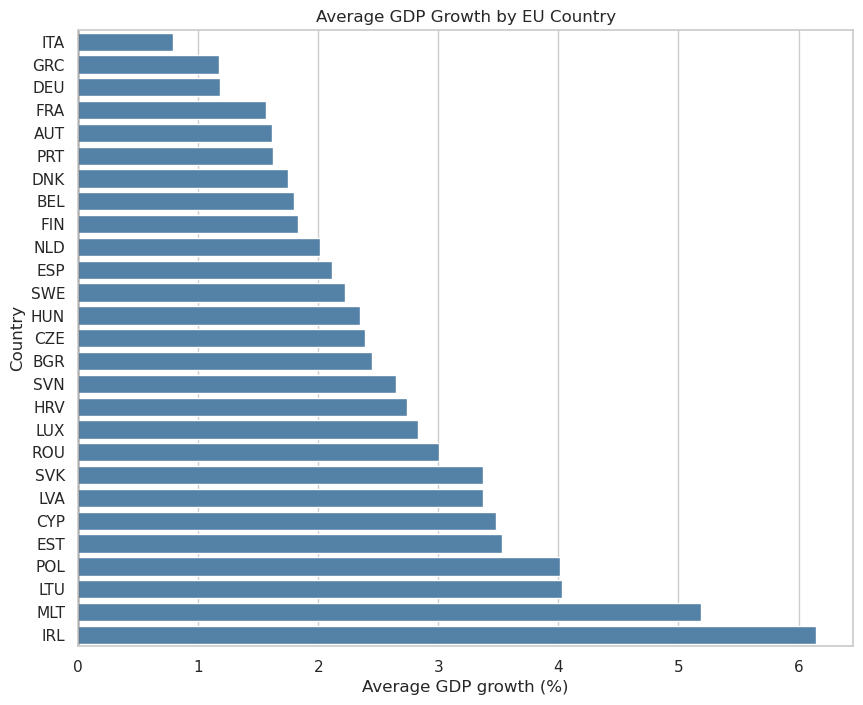

In [9]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=country_average_growth,
    x="gdp_growth",
    y="Country Code",
    color="steelblue"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Average GDP Growth by EU Country")
plt.xlabel("Average GDP growth (%)")
plt.ylabel("Country")
plt.show()

### Outliers

<Figure size 1400x800 with 0 Axes>

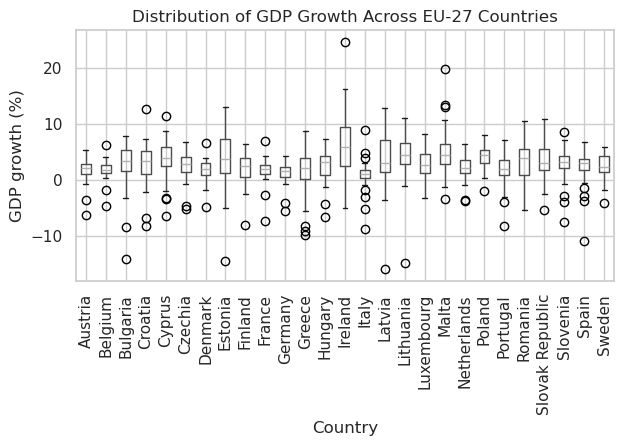

In [10]:
country_growth_summary = (
    data
    .groupby("Country Name")["gdp_growth"]
    .agg(["mean", "min", "max"])
    .sort_values("mean", ascending=False)
    .reset_index()
)

plt.figure(figsize=(14, 8))

data.boxplot(
    column="gdp_growth",
    by="Country Name",
    rot=90
)

plt.xlabel("Country")
plt.ylabel("GDP growth (%)")
plt.title("Distribution of GDP Growth Across EU-27 Countries")
plt.suptitle("")

plt.tight_layout()
plt.show()

## 5. Explore relationships between variables

A correlation matrix shows linear relationships between numerical variables.

Correlation does not prove causation. It is used here as an exploratory tool.

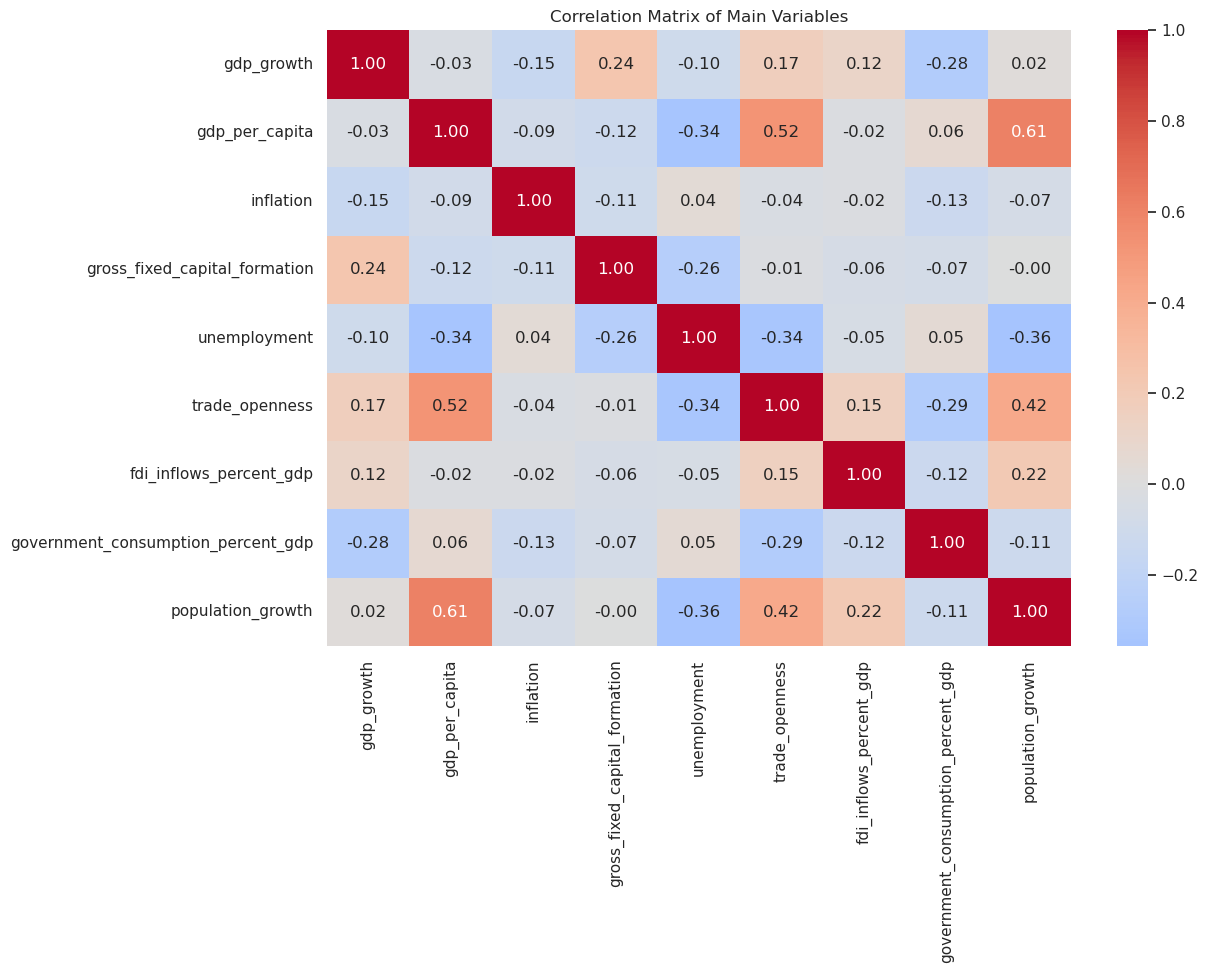

In [11]:
numeric_columns = [
    "gdp_growth",
    "gdp_per_capita",
    "inflation",
    "gross_fixed_capital_formation",
    "unemployment",
    "trade_openness",
    "fdi_inflows_percent_gdp",
    "government_consumption_percent_gdp",
    "population_growth"
]

correlation_matrix = data[numeric_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix of Main Variables")
plt.show()

## 6. Create lagged GDP-growth features

The model will use information from year `t` to predict GDP growth in year `t+1`.

For example:

```text
Indicators from 2024 → GDP growth in 2025

In [12]:
data = data.sort_values(
    ["Country Code", "Year"]
).reset_index(drop=True)

data["gdp_growth_lag_1"] = data["gdp_growth"]

data["gdp_growth_lag_2"] = (
    data
    .groupby("Country Code")["gdp_growth"]
    .shift(1)
)

data.head()

,Country Code,Country Name,Year,fdi_inflows_percent_gdp,inflation,government_consumption_percent_gdp,exports_percent_gdp,gross_fixed_capital_formation,imports_percent_gdp,gdp_growth,gdp_per_capita,unemployment,population_growth,trade_openness,gdp_growth_lag_1,gdp_growth_lag_2
0,AUT,Austria,1995,0.760156,2.243366,19.913675,33.665001,25.681435,34.860005,2.667984,33603.427826,4.345,0.153106,68.525006,2.667984,NaN
1,AUT,Austria,1996,1.832365,1.860971,19.919978,34.437736,25.979239,36.031581,2.215767,34301.656215,5.282,0.135020,70.469316,2.215767,2.667984
2,AUT,Austria,1997,1.260587,1.305979,19.907484,37.214434,25.541074,38.030042,2.145835,34998.032117,5.150,0.113317,75.244476,2.145835,2.215767
3,AUT,Austria,1998,2.106185,0.922467,19.880590,38.561591,25.582850,38.787931,3.492880,36180.749057,5.483,0.109728,77.349522,3.492880,2.145835
4,AUT,Austria,1999,1.374399,0.568994,20.132107,39.509313,25.079147,39.053620,3.761924,37468.869887,4.699,0.194563,78.562933,3.761924,3.492880


## 7. Create the next-year GDP-growth target

The target is created by shifting GDP growth backwards within each country.

This means that the indicators in year `t` are connected to GDP growth in year `t+1`.

In [13]:
data["target_gdp_growth_next_year"] = (
    data
    .groupby("Country Code")["gdp_growth"]
    .shift(-1)
)

data["target_year"] = data["Year"] + 1

data[
    [
        "Country Code",
        "Year",
        "target_year",
        "gdp_growth",
        "target_gdp_growth_next_year"
    ]
].head(10)

,Country Code,Year,target_year,gdp_growth,target_gdp_growth_next_year
0,AUT,1995,1996,2.667984,2.215767
1,AUT,1996,1997,2.215767,2.145835
2,AUT,1997,1998,2.145835,3.492880
3,AUT,1998,1999,3.492880,3.761924
4,AUT,1999,2000,3.761924,3.189523
5,AUT,2000,2001,3.189523,1.316987
6,AUT,2001,2002,1.316987,1.484369
7,AUT,2002,2003,1.484369,1.141565
8,AUT,2003,2004,1.141565,2.565255
9,AUT,2004,2005,2.565255,2.320365


In [14]:
data[
    [
        "Country Code",
        "Year",
        "target_year",
        "target_gdp_growth_next_year"
    ]
].tail()

,Country Code,Year,target_year,target_gdp_growth_next_year
832,SWE,2021,2022,1.255436
833,SWE,2022,2023,-0.204061
834,SWE,2023,2024,1.017796
835,SWE,2024,2025,1.543164
836,SWE,2025,2026,NaN


## 8. Create GDP-per-capita groups

GDP per capita will remain a continuous feature in the model.

We will also create economic-development groups for post-model performance analysis.

The groups will be based on average GDP per capita during the training period, not the future test period.

In [15]:
training_period_data = data[
    data["target_year"].between(1997, 2021)
].copy()

country_gdp_reference = (
    training_period_data
    .groupby(["Country Code", "Country Name"], as_index=False)
    ["gdp_per_capita"]
    .mean()
    .rename(columns={
        "gdp_per_capita": "average_training_gdp_per_capita"
    })
)

country_gdp_reference.head()

,Country Code,Country Name,average_training_gdp_per_capita
0,AUT,Austria,41645.578895
1,BEL,Belgium,38610.152421
2,BGR,Bulgaria,5909.494869
3,CYP,Cyprus,24309.038984
4,CZE,Czechia,15800.039078


In [16]:
country_gdp_reference["gdp_per_capita_group"] = pd.qcut(
    country_gdp_reference["average_training_gdp_per_capita"],
    q=3,
    labels=[
        "Lower GDP per capita",
        "Middle GDP per capita",
        "Higher GDP per capita"
    ]
)

country_gdp_reference[
    [
        "Country Code",
        "Country Name",
        "average_training_gdp_per_capita",
        "gdp_per_capita_group"
    ]
].sort_values("average_training_gdp_per_capita")

,Country Code,Country Name,average_training_gdp_per_capita,gdp_per_capita_group
2,BGR,Bulgaria,5909.494869,Lower GDP per capita
23,ROU,Romania,7331.887068,Lower GDP per capita
21,POL,Poland,10186.337999,Lower GDP per capita
18,LVA,Latvia,10501.291192,Lower GDP per capita
16,LTU,Lithuania,10974.671679,Lower GDP per capita
13,HUN,Hungary,11284.042594,Lower GDP per capita
12,HRV,Croatia,11408.797448,Lower GDP per capita
24,SVK,Slovak Republic,13169.998821,Lower GDP per capita
8,EST,Estonia,14757.134698,Lower GDP per capita
4,CZE,Czechia,15800.039078,Middle GDP per capita


In [17]:
data = data.merge(
    country_gdp_reference[
        ["Country Code", "gdp_per_capita_group"]
    ],
    on="Country Code",
    how="left"
)

data[
    ["Country Code", "Year", "gdp_per_capita_group"]
].head()

,Country Code,Year,gdp_per_capita_group
0,AUT,1995,Higher GDP per capita
1,AUT,1996,Higher GDP per capita
2,AUT,1997,Higher GDP per capita
3,AUT,1998,Higher GDP per capita
4,AUT,1999,Higher GDP per capita


## 9. Define the modelling dataset

The final modelling dataset must:

- Exclude 2025 feature rows because they do not have a 2026 target.
- Exclude rows without the required GDP lag features.
- Keep the 2025 target generated from 2024 predictors.

In [18]:
model_data = data[
    data["target_gdp_growth_next_year"].notna()
    & data["gdp_growth_lag_2"].notna()
].copy()

model_data = model_data.reset_index(drop=True)

print("Modelling rows:", model_data.shape[0])
print("Minimum target year:", model_data["target_year"].min())
print("Maximum target year:", model_data["target_year"].max())

Modelling rows: 783
Minimum target year: 1997
Maximum target year: 2025


## 10. Define the chronological split

The split is based on the target year.

Future years must not be used to train models predicting earlier years.

In [19]:
def assign_split(target_year):
    if 1997 <= target_year <= 2021:
        return "train"
    elif 2022 <= target_year <= 2025:
        return "test"
    else:
        return "outside_scope"


model_data["dataset_split"] = (
    model_data["target_year"]
    .apply(assign_split)
)

model_data["dataset_split"].value_counts().sort_index()

dataset_split
test     108
train    675
Name: count, dtype: int64

In [20]:
split_summary = (
    model_data
    .groupby("dataset_split")
    .agg(
        rows=("target_gdp_growth_next_year", "size"),
        first_target_year=("target_year", "min"),
        last_target_year=("target_year", "max")
    )
)

split_summary

,rows,first_target_year,last_target_year
dataset_split,,,
test,108,2022,2025
train,675,1997,2021


## 11. Check missing values before modelling

The FDI values are still missing at this stage.

They will be handled in the modelling notebook after the chronological train/test split.

In [21]:
model_data.isna().sum().sort_values(ascending=False)

fdi_inflows_percent_gdp               6
Country Code                          0
Country Name                          0
Year                                  0
inflation                             0
government_consumption_percent_gdp    0
exports_percent_gdp                   0
gross_fixed_capital_formation         0
imports_percent_gdp                   0
gdp_growth                            0
gdp_per_capita                        0
unemployment                          0
population_growth                     0
trade_openness                        0
gdp_growth_lag_1                      0
gdp_growth_lag_2                      0
target_gdp_growth_next_year           0
target_year                           0
gdp_per_capita_group                  0
dataset_split                         0
dtype: int64

## 12. Save the feature-engineered dataset

This dataset is prepared for modelling but has not yet had missing FDI values imputed.

In [22]:
model_data_path = (
    project_root
    / "data"
    / "processed"
    / "model_data_before_imputation.csv"
)

model_data.to_csv(model_data_path, index=False)

print("Saved modelling dataset to:")
print(model_data_path)

Saved modelling dataset to:
/home/ricci-preto/IronHack/Classes/ML Project/data/processed/model_data_before_imputation.csv


## Conclusion

The data is now ready for the modelling notebook.

We created:

- GDP-growth lag features.
- The next-year GDP-growth target.
- The target year.
- GDP-per-capita economic groups.
- Chronological train and test labels.

Missing FDI values remain documented and will be handled using training-data-only imputation in the next notebook.